<a href="https://colab.research.google.com/github/ThanushmaKuram/CN7030-2526-ML-ON-BIGDATA/blob/main/Week4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pyspark

In [2]:
from pyspark.sql import SparkSession

spark = SparkSession \
    .builder \
    .appName("Python Spark SQL basic example") \
    .config("spark.some.config.option", "some-value") \
    .getOrCreate()

In [3]:
from google.colab import drive
drive.mount

<function google.colab.drive.mount(mountpoint, force_remount=False, timeout_ms=120000, readonly=False)>

In [4]:
dataset = spark.read.csv('/content/titanic_synthetic_data.csv',inferSchema=True, header =True)

In [5]:
dataset.columns

['Pclass',
 'Age',
 'SibSp',
 'Parch',
 'Fare',
 'Sex',
 'Survived',
 'Embarked_Q',
 'Embarked_S']

In [6]:
print(dataset.head())

# For schema information, use printSchema()
dataset.printSchema()

print(dataset.describe().show())

# For null counts, iterate through columns
from pyspark.sql.functions import col, sum
dataset.select([sum(col(c).isNull().cast("int")).alias(c) for c in dataset.columns]).show()

Row(Pclass=3, Age=42, SibSp=6, Parch=7, Fare=397.00178367782024, Sex=0, Survived=0, Embarked_Q=0, Embarked_S=1)
root
 |-- Pclass: integer (nullable = true)
 |-- Age: integer (nullable = true)
 |-- SibSp: integer (nullable = true)
 |-- Parch: integer (nullable = true)
 |-- Fare: double (nullable = true)
 |-- Sex: integer (nullable = true)
 |-- Survived: integer (nullable = true)
 |-- Embarked_Q: integer (nullable = true)
 |-- Embarked_S: integer (nullable = true)

+-------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+
|summary|            Pclass|               Age|             SibSp|             Parch|              Fare|               Sex|          Survived|         Embarked_Q|        Embarked_S|
+-------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------

Value Counts for 'Survived':
Survived
0    500130
1    499870
Name: count, dtype: int64

Normalized Value Counts (%) for 'Survived':
Survived
0    50.013
1    49.987
Name: proportion, dtype: float64


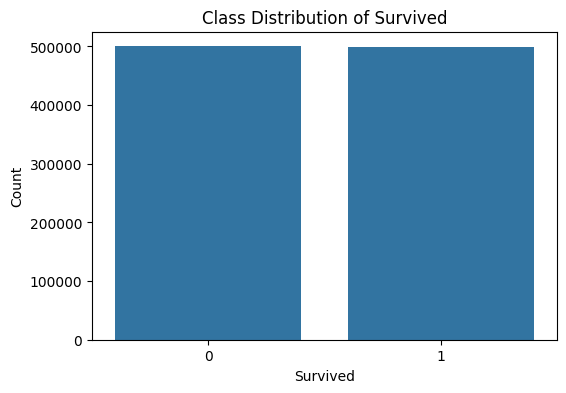

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the 'Survived' column from PySpark DataFrame to Pandas DataFrame for analysis
survived_data_pd = dataset.select('Survived').toPandas()

print("Value Counts for 'Survived':")
print(survived_data_pd['Survived'].value_counts())

print("\nNormalized Value Counts (%) for 'Survived':")
print(survived_data_pd['Survived'].value_counts(normalize=True)*100)

plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=survived_data_pd)
plt.title("Class Distribution of Survived")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

In [8]:
X = dataset.drop('Survived')
y = dataset.select('Survived')

In [9]:
ratio = y.toPandas()['Survived'].value_counts(normalize=True)

print(ratio)

Survived
0    0.50013
1    0.49987
Name: proportion, dtype: float64


In [10]:
if ratio.min() < 0.40:
    print("Dataset is imbalanced.")

    smote = SMOTE(random_state=42)
    X, y = smote.fit_resample(X, y)

    print(pd.Series(y).value_counts())

else:
    print("Dataset is balanced.")

Dataset is balanced.


In [11]:
from sklearn.model_selection import train_test_split

# Convert PySpark DataFrames to Pandas DataFrames
X_pd = X.toPandas()
y_pd = y.toPandas()

X_train, X_test, y_train, y_test = train_test_split(
    X_pd,
    y_pd,
    test_size=0.2,
    random_state=42,
    stratify=y_pd
)

In [12]:
from sklearn.linear_model import LogisticRegression
# Initialize the Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear') # Added solver for better convergence

model.fit(X_train, y_train.values.ravel())

LogisticRegression(random_state=42, solver='liblinear')

In [13]:
y_pred = model.predict(X_test)

In [14]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.49803

Confusion Matrix
[[53531 46495]
 [53899 46075]]

Classification Report
              precision    recall  f1-score   support

           0       0.50      0.54      0.52    100026
           1       0.50      0.46      0.48     99974

    accuracy                           0.50    200000
   macro avg       0.50      0.50      0.50    200000
weighted avg       0.50      0.50      0.50    200000

